# Laboratorio Avanzado 
### Estimación de parametros: de la minimización del residuo a $\chi^2$

Partiendo de un conjunto de datos experimentales, podemos encontrar la expresión matemática que mejor describe al experimento realizando un ajuste. La dificultad del ajuste dependerá de la precisión que pretendamos darle a nuestros resultados. La manera más sencilla de hacer el ajuste es mediante lo que se conoce como __"minimización del residuo"__.

El residuo está definido como:
\begin{equation}
R^2 = \sum_i [y_i - f(x_i, c_1, c_2, ...)]^2
\end{equation}
donde $y_i$ son los valores medidos, $f(x_i, c_1, c_2, ...)$ es el modelo al cual queremos ajustar nuestros datos (una recta, un polinomio, una función trigonométrica, etc.) y $c_n$ son los parámetros libres del modelo.

Este es el ajuste más sencillo y una de las razones es que __no consideramos los errores en la medición__, sino únicamente los valores medidos. Otra simplificación que podemos hacer es considerar un modelo lineal, por ejemplo, una línea recta:
\begin{equation}
f(x)=a+bx
\end{equation}

De esta manera, al minimizar $R^2$ respecto a los parámetros libres, o lo que es equivalente, minimizar la suma de las distancias cuadradas entre los puntos y la recta, podemos obtener los parámetros del ajuste:

\begin{equation}
\frac{\partial R^2}{\partial a} = 0,
\qquad
\frac{\partial R^2}{\partial b} = 0
\end{equation}

\begin{equation}
\Downarrow
\end{equation}

\begin{equation}
b = \frac{\sum x_i y_i - n\bar{x}\bar{y}}
{\sum x_i^2 - n\bar{x}^2}
\end{equation}

\begin{equation}
a = \frac{\bar{y}\sum x_i^2 - \bar{x}\sum x_i y_i}
{\sum x_i^2 - n\bar{x}^2}
\end{equation}

donde $n$ es el número de datos e $i = 1, 2, ..., n$.

El siguiente nivel es considerar errores estadísticos y para eso hacemos un ajuste de __"chi cuadráda" ($\chi^2$)__ que agrega un __peso a cada medición dada por la desviación o error estadístico asociado a ella__.

La expresión matemática es:
\begin{equation}
\chi^2 = \sum\left[\frac{(y_i - f(x_i, c_1, c_2, ...)^2}{\sigma_{y_i}(x_i)^2} \right]
\end{equation}
con $\sigma_{y_i}(x_i)$ es la varianza de $y$ en $x_i$. Este ajuste es válido para una distribución de datos independiente con errores que siguen una distribución gaussiana y son independientes unos de otros. Cambiar estas ultimas suposiciones agrega más grados de dificultad y presición estadística al análisis.

Por simplicidad, nuevamente asumimos un modelo de liena recta, por lo que la minimización será nuevamente respecto a los parámetros $a$ y $b$. Primero respecto a $a$:
\begin{equation}
\frac{\partial \chi^2}{\partial a} = -2\sum \left[\frac{y_i - a -bx_i}{\sigma_i^2}\right] = 0
\end{equation}
donde consideramos que la varianza no depende de a. Distribuyendo la sumatoria obtenemos
\begin{equation}
a\sum \frac{1}{\sigma^2_i} + b\sum \frac{x_i}{\sigma^2_i} = \sum \frac{y_i}{\sigma_i^2}
\tag{1}
\end{equation}

Ahora respecto a b:
\begin{equation}
\frac{\partial \chi^2}{\partial b} = -2\sum \left[\frac{x_i(y_i -a- bx_i)}{\sigma_i^2}\right] = 0
\end{equation}

Reorganizando los términos
\begin{equation}
a\sum \frac{x_i}{\sigma^2_i} + b\sum \frac{x_i^2}{\sigma^2_i} = \sum \frac{x_i y_i}{\sigma_i^2}
\tag{2}
\end{equation}

Del sistema de ecuaciones (1) y (2), 
\begin{equation}
a =
\frac{
\sum_i \frac{y_i}{\sigma_i^2}
\sum_i \frac{x_i^2}{\sigma_i^2}
\sum_i \frac{x_i}{\sigma_i^2}
\sum_i \frac{x_i y_i}{\sigma_i^2}
}
{
\sum_i \frac{1}{\sigma_i^2}
\sum_i \frac{x_i^2}{\sigma_i^2}
\left(\sum_i \frac{x_i}{\sigma_i^2}\right)^2
}
\end{equation}

\begin{equation}
b =
\frac{
\sum_i \frac{1}{\sigma_i^2}
\sum_i \frac{x_i y_i}{\sigma_i^2}
\sum_i \frac{x_i}{\sigma_i^2}
\sum_i \frac{y_i}{\sigma_i^2}
}
{
\sum_i \frac{1}{\sigma_i^2}
\sum_i \frac{x_i^2}{\sigma_i^2}
\left(\sum_i \frac{x_i}{\sigma_i^2}\right)^2
}
\end{equation}

### Funciones de Distribución de Probabilidad (PDF)

Veremos ejemplos de funciones de distribución que cambian dependiendo del sistema de coordenadas. Habrá casos en los que podemos asumir una distribución gaussiana (ya sea en los datos o en sus desviaciones), pero al realizar un cambio de variables esta propiedad puede dejar de cumplirse.

Esto ocurre porque al transformar coordenadas aparece un factor geométrico (Jacobiano) que modifica la distribución. Por lo tanto, una distribución uniforme o gaussiana en un sistema de coordenadas no necesariamente lo será en otro.

Para ejemplificar lo anterior, analicemos una distribución homogénea de puntos:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N=1000
x=np.random.uniform(0, 1, N)
y=np.random.uniform(0,1,N)

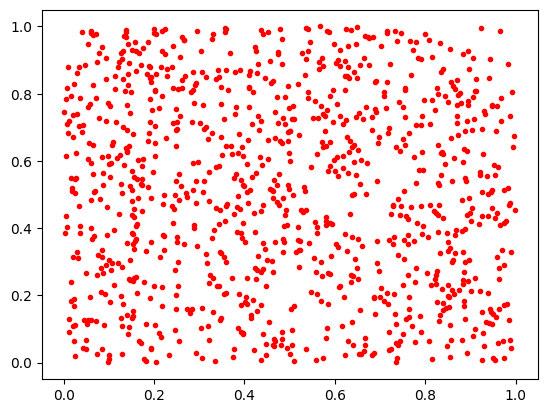

In [3]:
plt.plot(x, y, 'r.') 

Ahora, si pasamos esa distribución homogénea a un espacio de coordenadas polares veremos que la distribución de puntos es diferente:

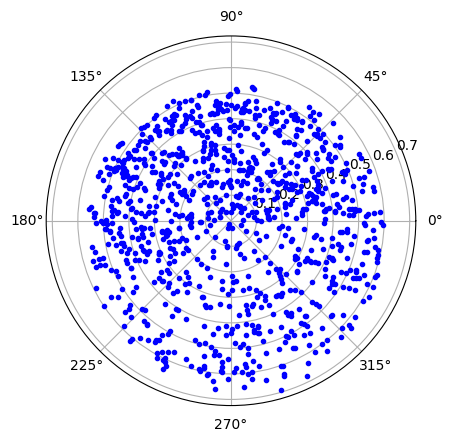

In [4]:
r_pol=np.sqrt((x/2)**2 + (y/2)**2)
theta = np.arctan2(y,x)
plt.polar(2*np.pi*theta, r_pol, 'b.')

Si intentamos partir de coordenadas polares aleatorias y graficar

In [10]:
r = np.random.rand(N)           ## Radio = 1
theta = 2*np.pi*np.random.rand(N)

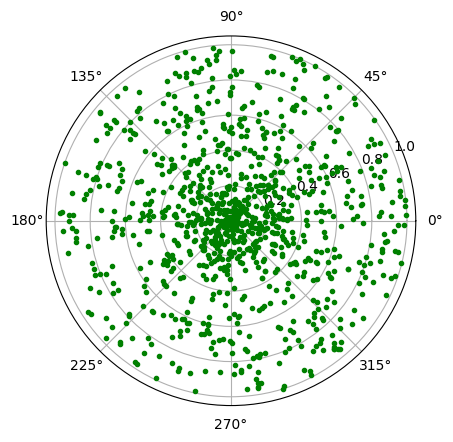

In [11]:
plt.polar(2*np.pi*theta, r, 'g.')

Vemos que tampoco funciona, porque se están generando igual de puntos entre r = 0 y r = 0.1 que entre r = 0.9 y r = 1 y para este útlimo, el área total a cubir con los puntos ya es más grande. Entonces, para general una distribución homogénea de puntos en un circulo, pasamos a coordenadas cartesianas (donde tiene más sentido la aleatoriedad de la variable r)

In [14]:
x = np.sqrt(r)*np.cos(theta)
y = np.sqrt(r)*np.sin(theta)

(-1.0930277836189748,
 1.0968290753952217,
 -1.0922170671276015,
 1.0841033529869977)

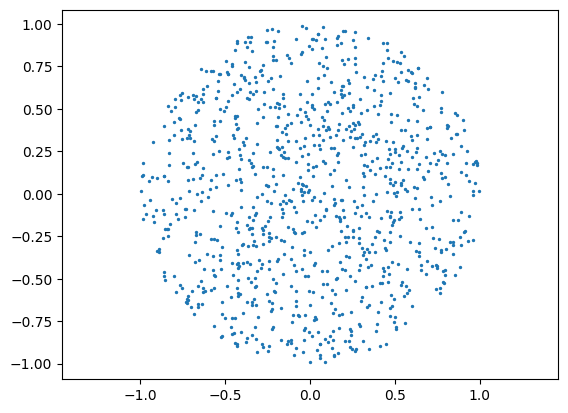

In [15]:
plt.scatter(x, y, s = 2)
plt.axis('equal')                    ## matplot no tiene la misma escala por defecto para x y y

Si ahora queremos volver al espacio polar, podemos regresar la transformación y graficar ahí

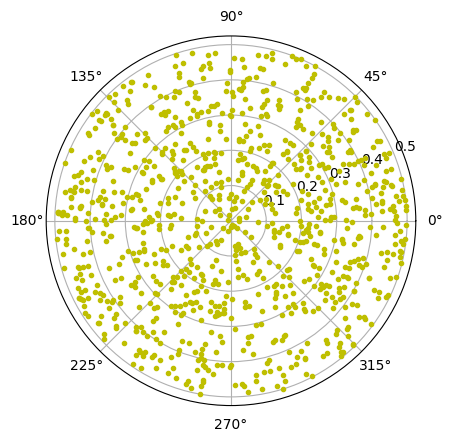

In [21]:
r_pol=np.sqrt((x/2)**2 + (y/2)**2)
theta = np.arctan2(y,x)
plt.polar(2*np.pi*theta, r_pol, 'y.')

Un ejemplo importante de transformaciones que cambian la distribución aparece en cosmología. Las perturbaciones primordiales se modelan como gaussianas. Al pasar al espacio de Fourier, estas siguen siendo gaussianas, ya que la transformada de Fourier es una transformación lineal y preserva la gaussianidad.

Sin embargo, durante la evolución temporal del universo (debido a la gravedad, velocidades peculiares, formación de estructura, etc.), este carácter gaussiano se pierde. Esto se debe a que la dinámica gravitacional introduce términos no lineales (por ejemplo, productos y potencias de la perturbación), y las transformaciones no lineales de variables gaussianas en general no son gaussianas.